In [1]:
# 1. Импорт библиотек

import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации
import torch # импортируем PyTorch
import torch.nn as nn #для создания нейронных сетей
import pytorch_lightning as pl

from sklearn import linear_model #линейные модели
from sklearn import metrics #метрики
from sklearn import preprocessing #предобработка
from sklearn.model_selection import train_test_split #разделение выборки
from sklearn import ensemble #ансамблевые методы

In [ ]:
# 2. Загрузка и анализ данных

train = pd.read_csv('/Users/konstantingeneralov/IDE/Data/DL_PJ_train.csv', sep=',')
test = pd.read_csv('/Users/konstantingeneralov/IDE/Data/DL_PJ_test.csv', sep=',')

df_train = train.copy()
df_test = test.copy()

display(df_train.head(), df_train.info(), df_train.describe())
display(df_test.head(), df_test.info(), df_test.describe())

# проверим кол-ва дубликатов в данных
duplicate_rows_train = df_train.duplicated().sum()
duplicate_rows_test = df_test.duplicated().sum()
print('Количество дубликатов в тренинговой выборке:', duplicate_rows_train)
print('Количество дубликатов в тестовой выборке:', duplicate_rows_test)

# проверим наличие пропущенных значений и уникальных значений в каждом столбце
summary = pd.DataFrame({
    "missing": df_train.isnull().sum(),
    "unique": df_train.nunique(),
    "dtype": df_train.dtypes
})
display('train',summary)

summary = pd.DataFrame({
    "missing": df_test.isnull().sum(),
    "unique": df_test.nunique(),
    "dtype": df_test.dtypes
})
display('test',summary)


<class 'pandas.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 15 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    600000 non-null  int64  
 1   age                                   600000 non-null  float64
 2   sex                                   600000 non-null  int64  
 3   chest                                 600000 non-null  float64
 4   resting_blood_pressure                600000 non-null  float64
 5   serum_cholestoral                     600000 non-null  float64
 6   fasting_blood_sugar                   600000 non-null  int64  
 7   resting_electrocardiographic_results  600000 non-null  int64  
 8   maximum_heart_rate_achieved           600000 non-null  float64
 9   exercise_induced_angina               600000 non-null  int64  
 10  oldpeak                               600000 non-null  float64
 11  slope      

,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
0,0,49.207124,0,4.000000,162.996167,181.108682,0,0,148.227858,1,0.944547,2,0,3,1
1,1,53.628425,1,1.741596,130.233730,276.474630,0,2,152.917139,0,0.119070,2,0,3,0
2,2,49.591426,1,4.000000,146.999012,223.300517,1,2,102.352090,1,1.616747,2,2,7,1
3,3,58.991445,1,4.000000,112.369143,187.245501,0,0,158.164750,1,0.000000,1,1,7,1
4,4,51.053602,1,1.954609,138.032047,238.482868,0,0,172.540828,0,1.150464,1,1,3,0


None

,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
count,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000
mean,299999.500000,54.426085,0.677447,3.170247,131.340485,249.592420,0.150757,1.020148,149.592069,0.333502,1.051391,1.596033,0.681303,4.711378,0.444185
std,173205.225094,9.086041,0.467454,0.949618,17.842450,51.699976,0.357812,0.994204,23.072593,0.471464,1.144288,0.629821,0.950669,1.934766,0.496875
min,0.000000,26.061695,0.000000,-0.538498,82.918527,98.326263,0.000000,0.000000,61.844168,0.000000,-0.806788,1.000000,0.000000,3.000000,0.000000
25%,149999.750000,48.078493,0.000000,3.000000,119.924094,216.475964,0.000000,0.000000,135.704237,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,299999.500000,55.133425,1.000000,3.000000,129.727941,244.233699,0.000000,2.000000,153.224828,0.000000,0.811101,2.000000,0.000000,3.000000,0.000000
75%,449999.250000,60.663775,1.000000,4.000000,139.915216,274.345453,0.000000,2.000000,165.165497,1.000000,1.674081,2.000000,1.000000,7.000000,1.000000
max,599999.000000,79.591647,1.000000,4.000000,209.673650,527.755764,1.000000,2.000000,208.735196,1.000000,6.803372,3.000000,3.000000,7.000000,1.000000


<class 'pandas.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 14 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    400000 non-null  int64  
 1   age                                   400000 non-null  float64
 2   sex                                   400000 non-null  int64  
 3   chest                                 400000 non-null  float64
 4   resting_blood_pressure                400000 non-null  float64
 5   serum_cholestoral                     400000 non-null  float64
 6   fasting_blood_sugar                   400000 non-null  int64  
 7   resting_electrocardiographic_results  400000 non-null  int64  
 8   maximum_heart_rate_achieved           400000 non-null  float64
 9   exercise_induced_angina               400000 non-null  int64  
 10  oldpeak                               400000 non-null  float64
 11  slope      

...

Количество дубликатов в тренинговой выборке: 0
Количество дубликатов в тестовой выборке: 0


'train'

,missing,unique,dtype
ID,0,600000,int64
age,0,594106,float64
sex,0,2,int64
chest,0,133009,float64
resting_blood_pressure,0,596241,float64
serum_cholestoral,0,598797,float64
fasting_blood_sugar,0,2,int64
resting_electrocardiographic_results,0,3,int64
maximum_heart_rate_achieved,0,597583,float64
exercise_induced_angina,0,2,int64


'test'

,missing,unique,dtype
ID,0,400000,int64
age,0,397391,float64
sex,0,2,int64
chest,0,90257,float64
resting_blood_pressure,0,398274,float64
serum_cholestoral,0,399436,float64
fasting_blood_sugar,0,2,int64
resting_electrocardiographic_results,0,3,int64
maximum_heart_rate_achieved,0,398888,float64
exercise_induced_angina,0,2,int64


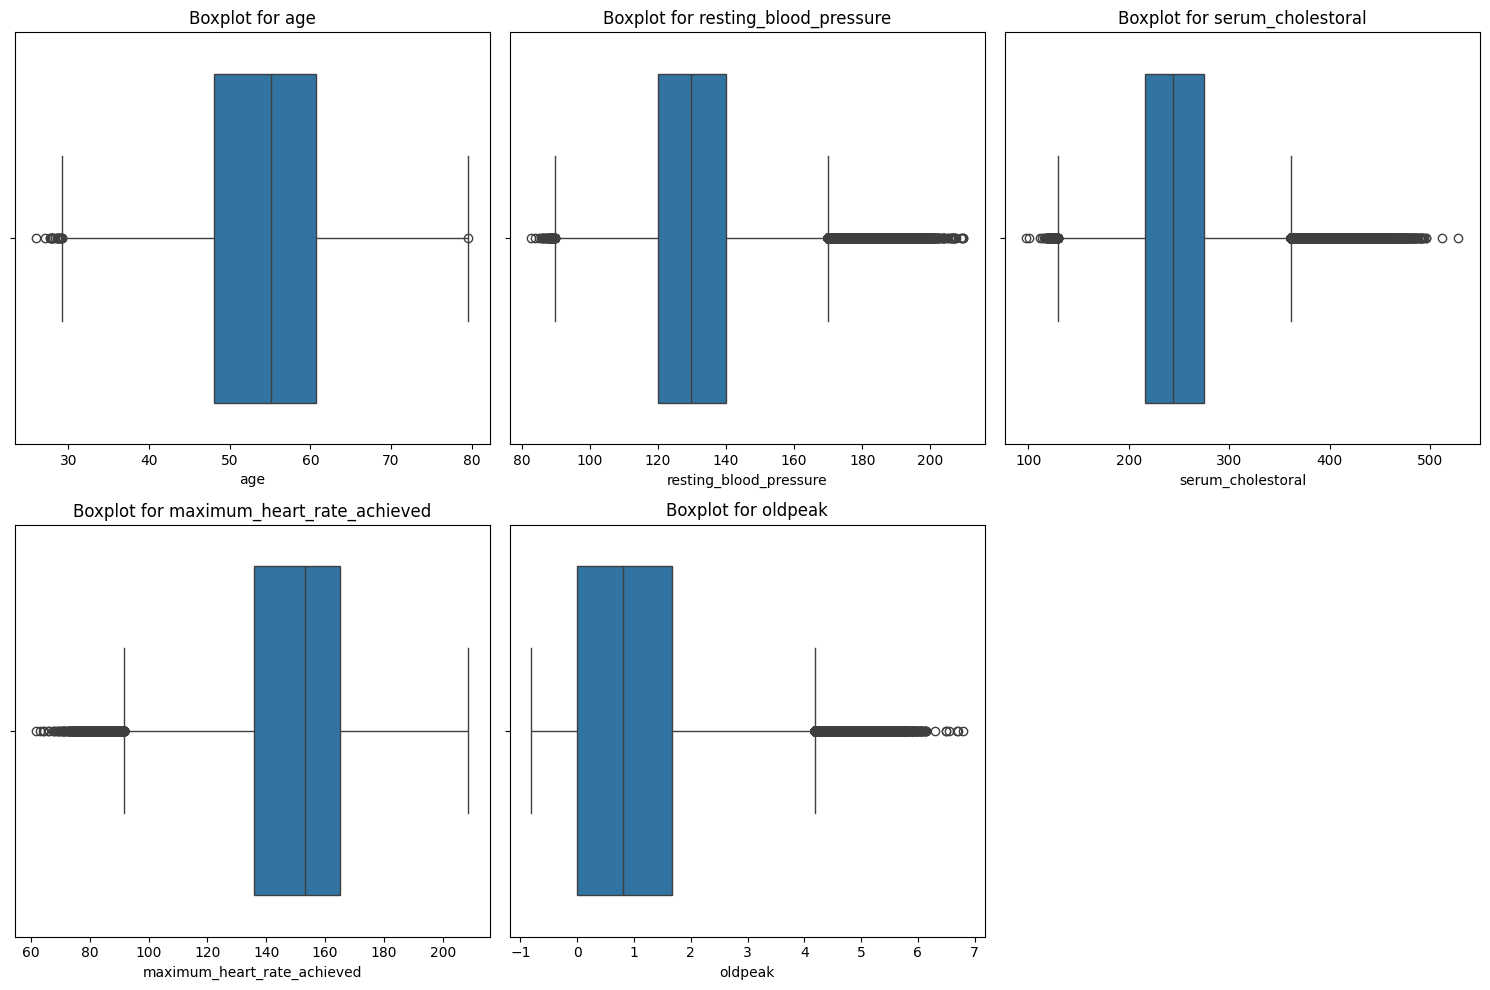

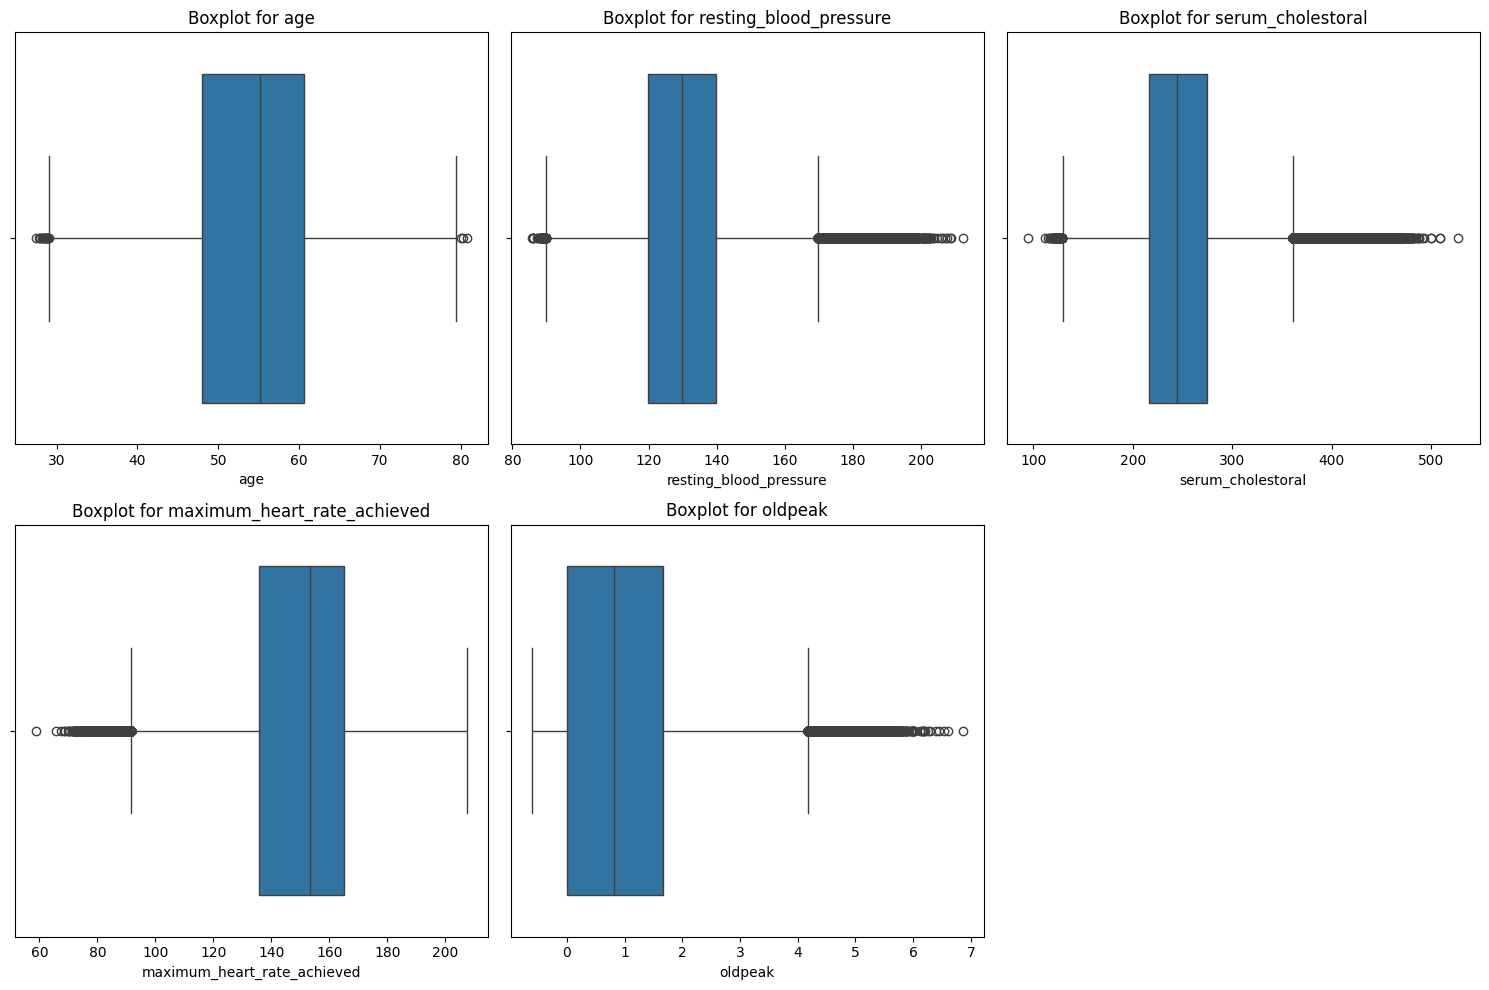

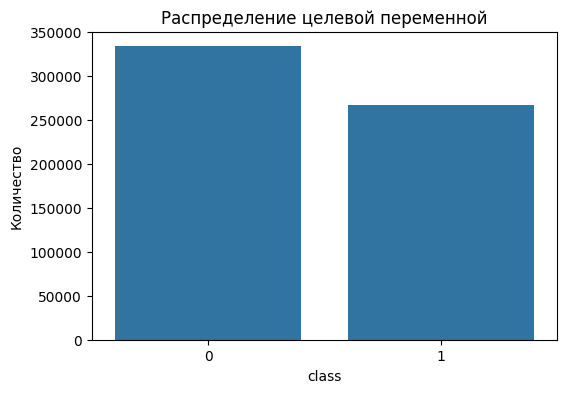

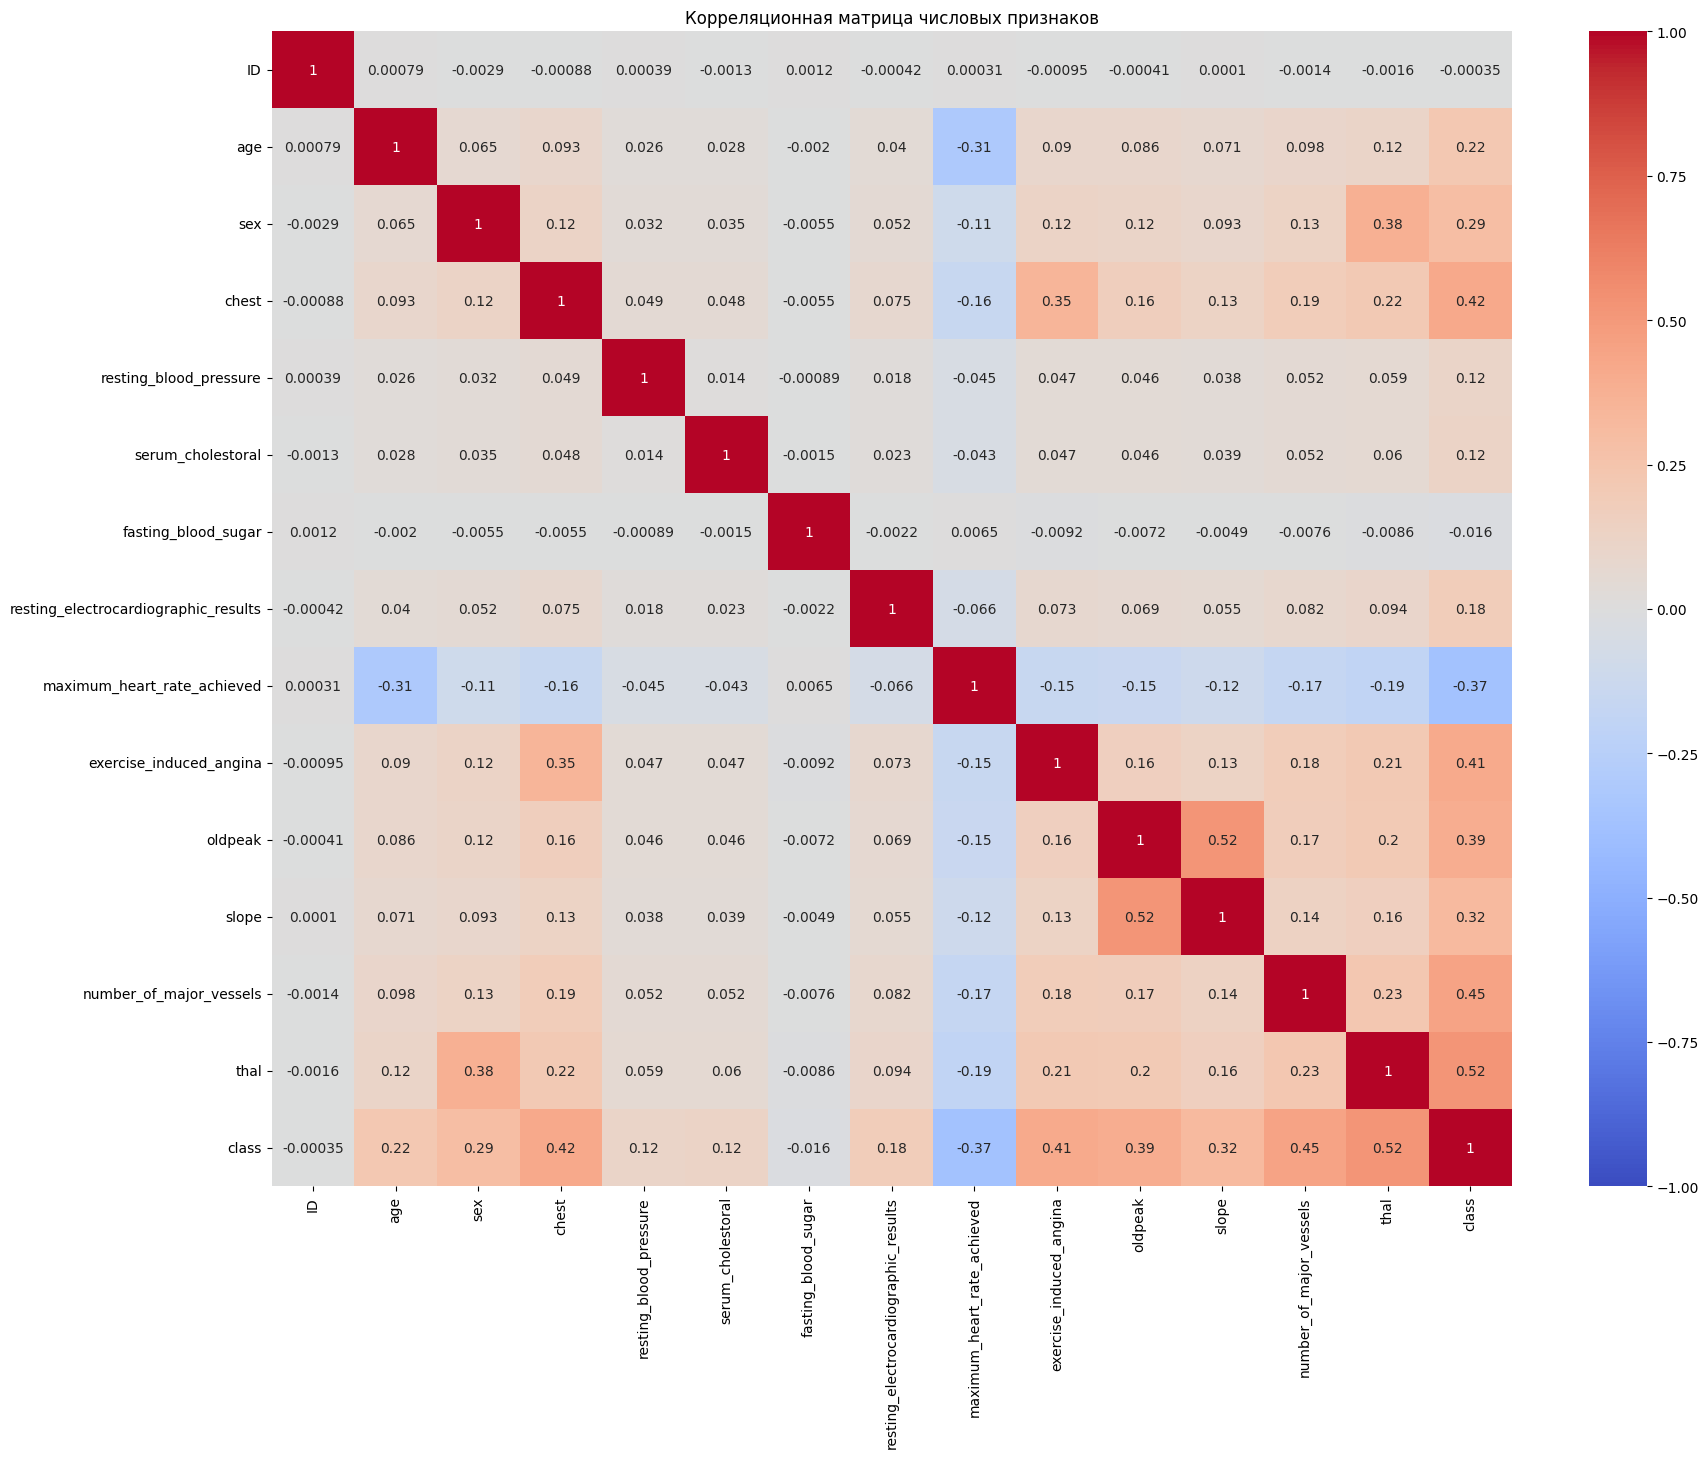

In [3]:
# посмотрим выбросы в числовых данных train
num_colls = ['age','resting_blood_pressure','serum_cholestoral','maximum_heart_rate_achieved','oldpeak']
plt.figure(figsize=(15,10))
for i, col in enumerate(num_colls):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=df_train[col])
    plt.title(f'Boxplot for {col}')
plt.tight_layout()
plt.show()

# посмотрим выбросы в числовых данных test
plt.figure(figsize=(15,10))
for i, col in enumerate(num_colls):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=df_test[col])
    plt.title(f'Boxplot for {col}')
plt.tight_layout()
plt.show()

# посмотрим распределение целевой переменной train
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df_train)
plt.title('Распределение целевой переменной')
plt.xlabel('class')
plt.ylabel('Количество')
plt.show()

num_colls_2 = ['age','resting_blood_pressure','serum_cholestoral','maximum_heart_rate_achieved','oldpeak','class']
# построим корреляционную матрицу для числовых признаков train
plt.figure(figsize=(20,15))
corr_matrix = df_train.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Корреляционная матрица числовых признаков')
plt.show()  


In [5]:
df_train_1 = df_train.copy()
df_test_1 = df_test.copy()

# 3. Предобработка данных
# удалим столбец id, так как он не несет полезной информации для модели
df_train_1 = df_train_1.drop('ID', axis=1)


# приведем в порядок столбец chest так как в нем должны быть категории 1 2 3 4 int 

df_train_1 = df_train_1[df_train_1["chest"].between(1,4)]
df_test_1 = df_test_1[df_test_1["chest"].between(1,4)]

df_train_1["chest"] = np.rint(df_train_1["chest"]).astype(int).astype("category")
df_test_1["chest"]  = np.rint(df_test_1["chest"]).astype(int).astype("category")

# проверим наличие пропущенных значений и уникальных значений в каждом столбце
summary = pd.DataFrame({
    "missing": df_train_1.isnull().sum(),
    "unique": df_train_1.nunique(),
    "dtype": df_train_1.dtypes
})
display('train',summary)

summary = pd.DataFrame({
    "missing": df_test_1.isnull().sum(),
    "unique": df_test_1.nunique(),
    "dtype": df_test_1.dtypes
})
display('test',summary)

display(df_train_1.head(), df_train_1.info(), df_train_1.describe())
display(df_test_1.head(), df_test_1.info(), df_test_1.describe())

'train'

,missing,unique,dtype
age,0,583919,float64
sex,0,2,int64
chest,0,4,category
resting_blood_pressure,0,585967,float64
serum_cholestoral,0,588439,float64
fasting_blood_sugar,0,2,int64
resting_electrocardiographic_results,0,3,int64
maximum_heart_rate_achieved,0,587270,float64
exercise_induced_angina,0,2,int64
oldpeak,0,378648,float64


'test'

,missing,unique,dtype
ID,0,393047,int64
age,0,390521,float64
sex,0,2,int64
chest,0,4,category
resting_blood_pressure,0,391380,float64
serum_cholestoral,0,392504,float64
fasting_blood_sugar,0,2,int64
resting_electrocardiographic_results,0,3,int64
maximum_heart_rate_achieved,0,391978,float64
exercise_induced_angina,0,2,int64


<class 'pandas.DataFrame'>
Index: 589608 entries, 0 to 599999
Data columns (total 14 columns):
 #   Column                                Non-Null Count   Dtype   
---  ------                                --------------   -----   
 0   age                                   589608 non-null  float64 
 1   sex                                   589608 non-null  int64   
 2   chest                                 589608 non-null  category
 3   resting_blood_pressure                589608 non-null  float64 
 4   serum_cholestoral                     589608 non-null  float64 
 5   fasting_blood_sugar                   589608 non-null  int64   
 6   resting_electrocardiographic_results  589608 non-null  int64   
 7   maximum_heart_rate_achieved           589608 non-null  float64 
 8   exercise_induced_angina               589608 non-null  int64   
 9   oldpeak                               589608 non-null  float64 
 10  slope                                 589608 non-null  int64   
 11  num

...

,age,sex,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
count,589608.000000,589608.000000,589608.000000,589608.000000,589608.000000,589608.000000,589608.000000,589608.000000,589608.000000,589608.000000,589608.000000,589608.000000,589608.000000
mean,54.444573,0.678812,131.353423,249.630447,0.150827,1.021625,149.517931,0.336834,1.055291,1.597631,0.684828,4.720777,0.448459
std,9.081746,0.466933,17.848790,51.697144,0.357881,0.994160,23.081713,0.472628,1.146073,0.629735,0.952072,1.936056,0.497337
min,26.061695,0.000000,82.918527,98.326263,0.000000,0.000000,61.844168,0.000000,-0.806788,1.000000,0.000000,3.000000,0.000000
25%,48.103905,0.000000,119.930207,216.512633,0.000000,0.000000,135.623332,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,55.154679,1.000000,129.731662,244.266202,0.000000,2.000000,153.166667,0.000000,0.818534,2.000000,0.000000,3.000000,0.000000
75%,60.671902,1.000000,139.922644,274.372142,0.000000,2.000000,165.121941,1.000000,1.677361,2.000000,1.000000,7.000000,1.000000
max,79.591647,1.000000,209.673650,527.755764,1.000000,2.000000,208.735196,1.000000,6.803372,3.000000,3.000000,7.000000,1.000000


<class 'pandas.DataFrame'>
Index: 393047 entries, 0 to 399999
Data columns (total 14 columns):
 #   Column                                Non-Null Count   Dtype   
---  ------                                --------------   -----   
 0   ID                                    393047 non-null  int64   
 1   age                                   393047 non-null  float64 
 2   sex                                   393047 non-null  int64   
 3   chest                                 393047 non-null  category
 4   resting_blood_pressure                393047 non-null  float64 
 5   serum_cholestoral                     393047 non-null  float64 
 6   fasting_blood_sugar                   393047 non-null  int64   
 7   resting_electrocardiographic_results  393047 non-null  int64   
 8   maximum_heart_rate_achieved           393047 non-null  float64 
 9   exercise_induced_angina               393047 non-null  int64   
 10  oldpeak                               393047 non-null  float64 
 11  slo

,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal
0,600000,53.963191,1,4,136.940829,236.862814,0,2,143.961525,1,0.711100,1,2,7
1,600001,49.621479,1,4,122.024651,226.593019,0,2,112.220874,1,0.000000,1,1,7
2,600002,36.933893,1,1,127.585643,351.061046,0,0,177.945922,0,0.313078,1,0,7
3,600003,54.884588,1,3,124.876745,250.370530,0,0,153.176526,0,0.308277,1,1,7
4,600004,71.016392,0,2,120.922600,210.979710,0,0,164.573122,0,1.021370,1,1,3


None

,ID,age,sex,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal
count,393047.000000,393047.000000,393047.000000,393047.000000,393047.000000,393047.000000,393047.000000,393047.000000,393047.000000,393047.000000,393047.000000,393047.000000,393047.000000
mean,800018.069401,54.423906,0.678074,131.383728,249.654508,0.151239,1.027292,149.580464,0.336545,1.054007,1.596796,0.685104,4.715858
std,115460.109538,9.095228,0.467215,17.866858,51.733310,0.358282,0.994060,23.077973,0.472528,1.142749,0.628215,0.951951,1.934754
min,600000.000000,27.496874,0.000000,85.956184,94.958220,0.000000,0.000000,58.964662,0.000000,-0.601414,1.000000,0.000000,3.000000
25%,700036.500000,48.045284,0.000000,119.954108,216.484516,0.000000,0.000000,135.721793,0.000000,0.000000,1.000000,0.000000,3.000000
50%,800022.000000,55.148968,1.000000,129.741148,244.329294,0.000000,2.000000,153.276050,0.000000,0.823415,2.000000,0.000000,3.000000
75%,900033.500000,60.673317,1.000000,139.942586,274.401747,0.000000,2.000000,165.171001,1.000000,1.674864,2.000000,1.000000,7.000000
max,999999.000000,80.751628,1.000000,212.300808,527.712687,1.000000,2.000000,207.412021,1.000000,6.856219,3.000000,3.000000,7.000000


In [6]:
# делаем one-hot encoding для категориальных признаков
cat_coll = ['sex','chest','fasting_blood_sugar','resting_electrocardiographic_results','exercise_induced_angina','slope','number_of_major_vessels','thal']
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(
    sparse_output=False,      # если sklearn старый — можно sparse=False 
    drop='first',           # удаляем первую категорию, чтобы избежать мультиколлинеарности
    handle_unknown='ignore'
)

df_train_1_encoded = pd.DataFrame(
    encoder.fit_transform(df_train_1[cat_coll]),
    index=df_train_1.index,
    columns=encoder.get_feature_names_out(cat_coll)
)

df_test_1_encoded = pd.DataFrame(
    encoder.transform(df_test_1[cat_coll]),
    index=df_test_1.index,
    columns=encoder.get_feature_names_out(cat_coll)
)


#display(df_train_1_encoded.head(), df_train_1_encoded.info(), df_train_1_encoded.describe())
#display(df_test_1_encoded.head(), df_test_1_encoded.info(), df_test_1_encoded.describe())


In [11]:
# обучим модель 
num_colls = ['age','resting_blood_pressure','serum_cholestoral','maximum_heart_rate_achieved','oldpeak']

target_col = 'class'
x_train_num = df_train_1[num_colls]
x_test_num = df_test_1[num_colls]

X_train = pd.concat([x_train_num, df_train_1_encoded], axis=1) # склеили колонки числовые и закодированные категориальные
X_test = pd.concat([x_test_num, df_test_1_encoded], axis=1) # склеили колонки числовые и закодированные категориальные

y_train = df_train_1[target_col].astype(int) # преобразуем целевую переменную в int


print("X_train:", X_train.shape, "y_train:", y_train.shape, "X_test:", X_test.shape)




X_train: (589608, 20) y_train: (589608,) X_test: (393047, 20)


In [12]:
# 4. Разделим данные на обучающую и валидационную выборки
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train)

print("X_tr:", X_tr.shape, "y_tr:", y_tr.shape, "X_val:", X_val.shape, "y_val:", y_val.shape)

X_tr: (471686, 20) y_tr: (471686,) X_val: (117922, 20) y_val: (117922,)


In [13]:
# 4. Обучение модели
# используем логистическую регрессию

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

scaler = StandardScaler()

X_tr_lr = X_tr.copy()
X_val_lr = X_val.copy()

X_tr_lr[num_colls] = scaler.fit_transform(X_tr[num_colls])
X_val_lr[num_colls] = scaler.transform(X_val[num_colls])

logreg = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
logreg.fit(X_tr_lr, y_tr)

val_proba_lr = logreg.predict_proba(X_val_lr)[:, 1]
print("LogReg ROC-AUC:", roc_auc_score(y_val, val_proba_lr))

LogReg ROC-AUC: 0.9561421925512841


In [18]:
# 4. Обучение модели
# обучим модель случайного леса

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=1000,
    random_state=42,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    n_jobs=-1,
    class_weight="balanced_subsample"
)
rf.fit(X_tr, y_tr)

val_proba_rf = rf.predict_proba(X_val)[:, 1]
print("RF ROC-AUC:", roc_auc_score(y_val, val_proba_rf))

RF ROC-AUC: 0.9579210728287899


In [15]:
best_rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

best_rf.fit(X_train, y_train)



test_proba = best_rf.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

submission = pd.DataFrame({
    "ID": df_test_1["ID"].values,
    "class": test_pred
})

submission.to_csv("/Users/konstantingeneralov/IDE/Data/DL_PJ_submission.csv", index=False)
submission.head()

KeyboardInterrupt: 

In [16]:
from sklearn import tree

dt = tree.DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt.fit(X_tr, y_tr)  
val_proba_dt = dt.predict_proba(X_val)[:, 1]
print("DT ROC-AUC:", roc_auc_score(y_val, val_proba_dt))

DT ROC-AUC: 0.8475290554962026


In [17]:
# проверим наличие пропущенных значений и уникальных значений в каждом столбце
summary = pd.DataFrame({
    "missing": df_train_1.isnull().sum(),
    'duplicated': df_train_1.duplicated().sum(),
    "unique": df_train_1.nunique(),
    "dtype": df_train_1.dtypes})
display('train',summary)

summary = pd.DataFrame({
    "missing": df_test_1.isnull().sum(),
    'duplicated': df_test_1.duplicated().sum(),
    "unique": df_test_1.nunique(),
    "dtype": df_test_1.dtypes})
display('test',summary)

'train'

,missing,duplicated,unique,dtype
age,0,0,583919,float64
sex,0,0,2,int64
chest,0,0,4,category
resting_blood_pressure,0,0,585967,float64
serum_cholestoral,0,0,588439,float64
fasting_blood_sugar,0,0,2,int64
resting_electrocardiographic_results,0,0,3,int64
maximum_heart_rate_achieved,0,0,587270,float64
exercise_induced_angina,0,0,2,int64
oldpeak,0,0,378648,float64


'test'

,missing,duplicated,unique,dtype
ID,0,0,393047,int64
age,0,0,390521,float64
sex,0,0,2,int64
chest,0,0,4,category
resting_blood_pressure,0,0,391380,float64
serum_cholestoral,0,0,392504,float64
fasting_blood_sugar,0,0,2,int64
resting_electrocardiographic_results,0,0,3,int64
maximum_heart_rate_achieved,0,0,391978,float64
exercise_induced_angina,0,0,2,int64


In [28]:
df_train_new = df_train_1.copy()
df_test_new = df_test_1.copy()

df_train_new['chest'] = df_train_new['chest'].astype('int')
df_test_new['chest'] = df_test_new['chest'].astype('int')

new_cat_cols = ['sex','chest','fasting_blood_sugar','resting_electrocardiographic_results','exercise_induced_angina','slope','number_of_major_vessels','thal']

X = df_train_new.drop('class', axis=1)
y = df_train_new['class']

import lightgbm as lgb
import catboost as cb
from sklearn.metrics import roc_auc_score

x_train_new, x_val_new, y_train_new, y_val_new = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

catboost_model = cb.CatBoostClassifier(
    iterations=300, # это гиперпараметр, который определяет количество деревьев, которые будут построены в модели. Большее количество итераций может улучшить производительность модели, но также может привести к переобучению. Обычно рекомендуется начинать с 1000 итераций и экспериментировать с этим параметром.
    learning_rate=0.05, # это гиперпараметр, который показывает, насколько сильно модель будет обновляться на каждом этапе обучения. Меньшее значение может привести к более стабильному обучению, но потребует больше итераций для достижения хороших результатов.
    depth=6, # это гиперпараметр, который определяет максимальную глубину деревьев в модели. Глубокие деревья могут захватывать сложные зависимости в данных, но могут привести к переобучению. Обычно рекомендуется начинать с глубины 6 и экспериментировать с ней.
    eval_metric='AUC', # это метрика, которая будет использоваться для оценки производительности модели на валидационной выборке. AUC (Area Under the Curve) является популярной метрикой для задач классификации, особенно при работе с несбалансированными данными.
    cat_features=new_cat_cols, # это список категориальных признаков, которые будут использоваться в модели. CatBoost автоматически обрабатывает категориальные признаки, что может улучшить производительность модели.
    random_state=42
)

catboost_model.fit(x_train_new, y_train_new, eval_set=[(x_val_new, y_val_new)], early_stopping_rounds=50, verbose=False) # это метод, который обучает модель на тренировочных данных. eval_set используется для оценки производительности модели на валидационной выборке, а early_stopping_rounds позволяет остановить обучение, если производительность модели не улучшается в течение определенного количества итераций (в данном случае 50). verbose=False отключает вывод информации о процессе обучения.

val_proba_cat = catboost_model.predict_proba(x_val_new)[:, 1]
print("CatBoost ROC-AUC:", roc_auc_score(y_val_new, val_proba_cat))


CatBoost ROC-AUC: 0.965714122456809


In [29]:
new_cat_cols_2 = new_cat_cols.copy()

X = df_train_new.drop('class',axis=1)
y = df_train_new['class']

from sklearn.model_selection import train_test_split

x_train_new_2, x_val_2, y_train_new_2, y_val_2 = train_test_split(
    X, y,
    test_size= 0.2,
    random_state=42,
    stratify=y
)

new_catboost_model = cb.CatBoostClassifier(
    iterations= 500,
    learning_rate= 0.05,
    depth= 7,
    random_state= 42
)

new_catboost_model.fit(x_train_new_2,y_train_new_2, eval_set= [(x_val_new, y_val_new)], verbose=False)

val_proba_cat_new = new_catboost_model.predict_proba(x_val_new)[:, 1]
print('new_catboost_roc_auc', roc_auc_score(y_val_2, val_proba_cat_new))

new_catboost_roc_auc 0.9659412049296425


In [33]:
summary = pd.DataFrame({
    'missing': df_train_1.isnull().sum(),
    'duplicated': df_train_1.duplicated().sum(),
    'unique': df_train_1.nunique(),
    'type': df_train_1.dtypes
})
display("df_train_1", summary)

'df_train_1'

,missing,duplicated,unique,type
age,0,0,583919,float64
sex,0,0,2,int64
chest,0,0,4,category
resting_blood_pressure,0,0,585967,float64
serum_cholestoral,0,0,588439,float64
fasting_blood_sugar,0,0,2,int64
resting_electrocardiographic_results,0,0,3,int64
maximum_heart_rate_achieved,0,0,587270,float64
exercise_induced_angina,0,0,2,int64
oldpeak,0,0,378648,float64
